## Titanic Dataset EDA

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df = pd.read_csv("train.csv")


Dataset Overview

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Missing Values Analysis

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Observation

Missing values in Age and Embarked were filled using appropriate methods. The Cabin column contained a large number of missing values and was not used in the main analysis.

Data Cleaning

In [9]:
df["Age"].isnull().sum()
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"].isnull().sum()
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Cabin"].isnull().sum()

np.int64(687)

Observation

Missing values in the Age column were filled using the median. Missing values in the Embarked column were filled using the mode. The Cabin column contained 687 missing values and was not used in the main analysis

Survival Analysis

In [10]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


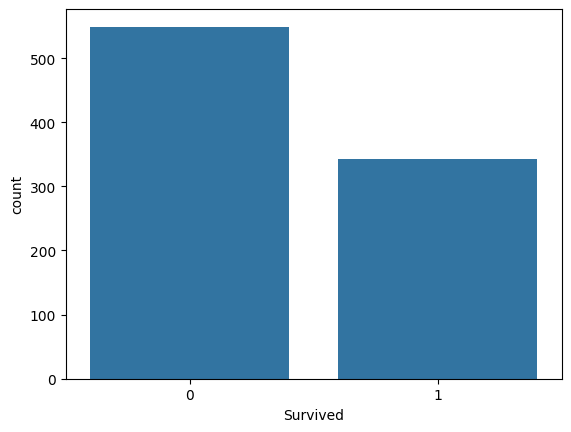

In [11]:
sns.countplot(x="Survived", data=df)
plt.show()

Observation

The dataset contains both survivors and non-survivors. More passengers did not survive than survived.

Gender vs Survival

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


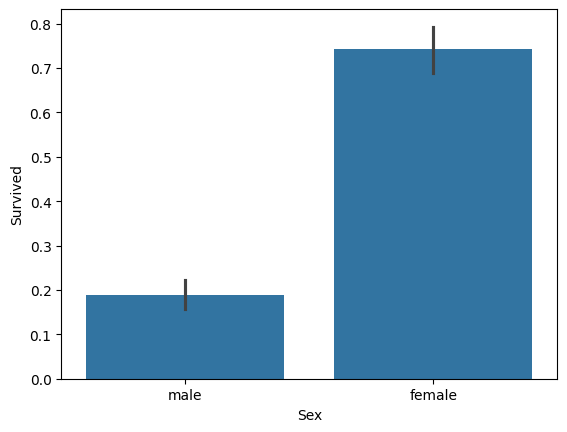

In [12]:
survival_rate = df.groupby("Sex")["Survived"].mean()
print(survival_rate)
sns.barplot(x="Sex", y="Survived", data=df)
plt.show()

Observation

Female passengers had a significantly higher survival rate than male passengers.
Gender appears to be an important factor affecting survival.

Passenger Class vs Survival

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


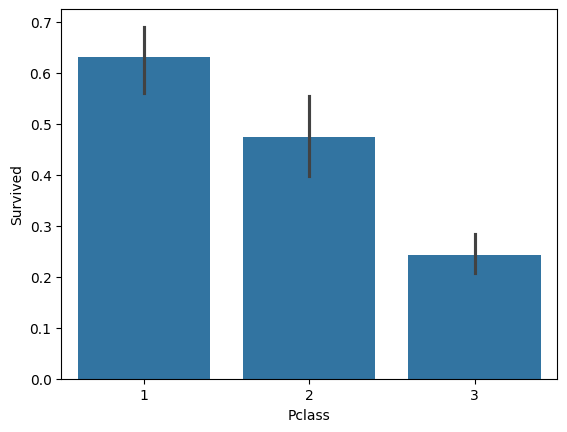

In [13]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()
print(survival_by_class)
sns.barplot(x="Pclass", y="Survived", data=df)
plt.show()

Observation

First-class passengers had the highest survival rate, while third-class passengers had the lowest. Passenger class seems to have a strong relationship with survival.

Age vs Survival

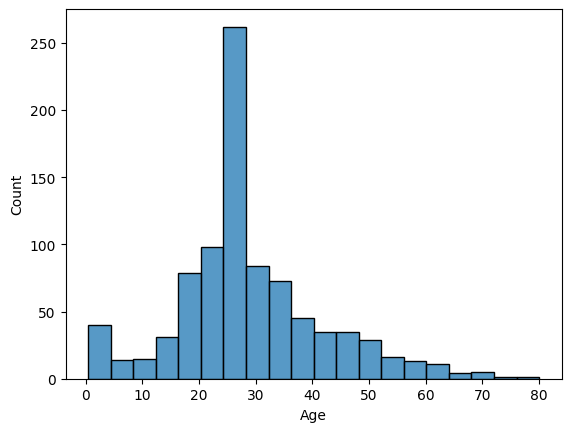

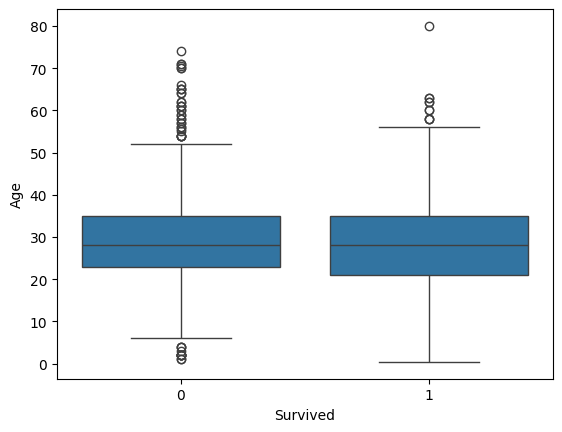

In [14]:
sns.histplot(df["Age"], bins=20)
plt.show()
sns.boxplot(x="Survived", y="Age", data=df)
plt.show()

Observation

There is some difference in the age distribution of survivors and non-survivors. Age may have influenced survival chances.

Fare vs Survival

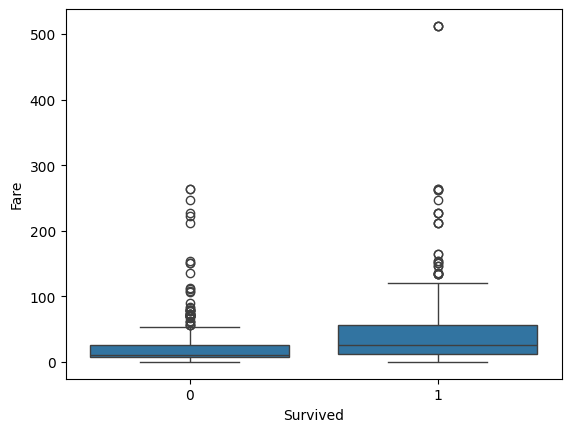

In [15]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.show()

Observation

Passengers who paid higher fares generally had better survival rates. Fare appears to be related to survival.

SibSp vs Survival

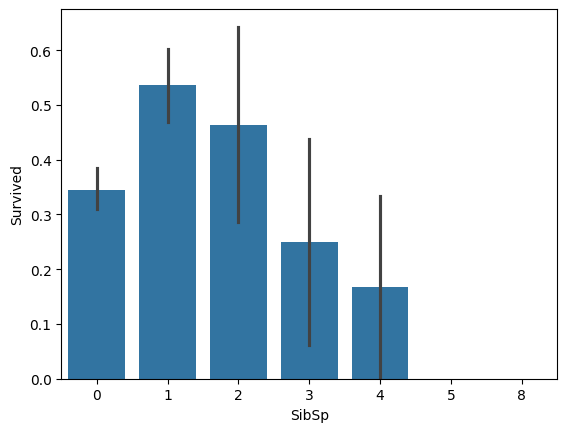

In [16]:
df.groupby("SibSp")["Survived"].mean()
sns.barplot(x="SibSp", y="Survived", data=df)
plt.show()

Observation

The number of siblings or spouses traveling with a passenger showed some effect on survival. Small family groups tended to have better survival rates.

Parch vs Survival

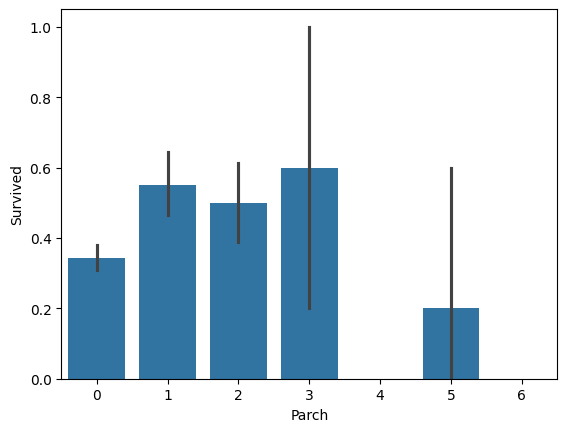

In [17]:
df.groupby("Parch")["Survived"].mean()
sns.barplot(x="Parch", y="Survived", data=df)
plt.show()

Observation

The number of parents or children traveling with a passenger showed some relationship with survival. Family connections may have influenced survival chances.

Embarked vs Survival

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


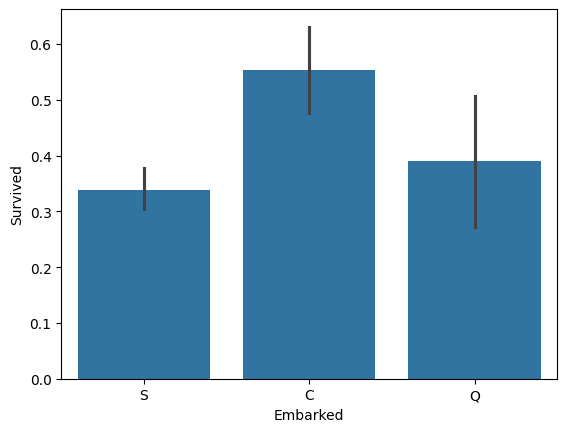

In [18]:
survival_by_embarked = df.groupby("Embarked")["Survived"].mean()
print(survival_by_embarked)
sns.barplot(x="Embarked", y="Survived", data=df)
plt.show()

Observation

Survival rates varied across different embarkation ports. However, the impact was not as strong as gender or passenger class.

Feature Engineering

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


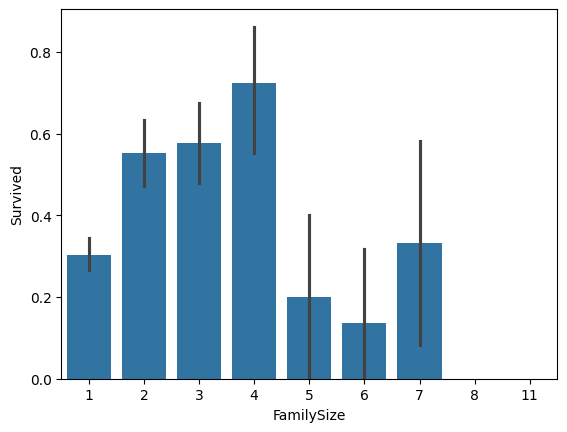

In [19]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
family_survival = df.groupby("FamilySize")["Survived"].mean()
print(family_survival)
sns.barplot(x="FamilySize", y="Survived", data=df)
plt.show()

Observation

A new feature called FamilySize was created using SibSp and Parch. Passengers traveling in small families generally had better survival rates than those traveling alone or in very large families.

## Useful vs Less Useful Features

Useful Features
* Sex
* Pclass
* Age
* Fare
* SibSp
* Parch
* Embarked
* FamilySize    

Less Useful Features
* PassengerId
* Ticket

* Cabin

  The Cabin column contains a large number of missing values (687 missing entries out of 891 records). Therefore, it was not used in the main analysis and would require additional preprocessing before being used effectively.

## Key Findings

1. Gender was one of the strongest factors affecting survival. Female passengers had a survival rate of approximately 74%, while male passengers had a survival rate of only about 19%.

2. Passenger class showed a strong relationship with survival. First-class passengers had the highest survival rate (63%), followed by second-class passengers (47%), while third-class passengers had the lowest survival rate (24%).

3. The port of embarkation appeared to influence survival. Passengers who boarded at Cherbourg (C) had a higher survival rate (55%) compared to Southampton (S) and Queenstown (Q).

4. Family-related features showed interesting. After creating the FamilySize feature, it was observed that passengers traveling in small families (2–4 members) generally had higher survival rates, while very large families had lower survival rates.

6. Missing values were identified in Age, Cabin, and Embarked columns. Age was filled using the median value, Embarked was filled using the mode, and Cabin was noted as having a large number of missing values.

7. Based on the analysis, Sex, Pclass, Fare, Age, Embarked, and FamilySize appear to be useful features for predicting survival.

# Machine Learning Model Building

In [20]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [21]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
 12  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


In [22]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [23]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [24]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2,1


# Feature Selection

In [25]:
X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = df['Survived']

In [26]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (891, 8)
Target Shape: (891,)


## Feature Selection

The target variable is Survived.

The columns Name, Ticket, Cabin, and PassengerId were removed because they either contained text data, had many missing values, or did not contribute significantly to survival prediction.

## Train Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (712, 8)
Testing Data : (179, 8)


## Feature Scaling

In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Logistic Regression

In [30]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [31]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy_lr)

Accuracy: 0.8044692737430168


# Decision Tree

In [32]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [33]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy:", accuracy_dt)

Accuracy: 0.7821229050279329


# K-Nearest Neighbors (KNN)

In [34]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [35]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy:", accuracy_knn)

Accuracy: 0.8212290502793296


# Support Vector Machine (SVM)

In [36]:
svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [37]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy:", accuracy_svm)

Accuracy: 0.8156424581005587


# Performance Evaluation

## Performance Metrics

### Accuracy
Accuracy = (TP + TN)/(TP + TN + FP + FN)

Measures the overall correctness of the model.

### Precision
Precision = TP/(TP + FP)

Measures how many predicted survivors were actually survivors.

### Recall
Recall = TP/(TP + FN)

Measures how many actual survivors were correctly identified.

### F1 Score
F1 Score = 2 × (Precision × Recall)/(Precision + Recall)

Provides a balance between Precision and Recall.

In [38]:
def evaluate_model(y_true, y_pred):

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

    print("\nClassification Report:\n")

    print(classification_report(y_true, y_pred))

In [39]:
print("LOGISTIC REGRESSION")

evaluate_model(y_test, y_pred_lr)

LOGISTIC REGRESSION
Accuracy : 0.8044692737430168
Precision: 0.782608695652174
Recall   : 0.7297297297297297
F1 Score : 0.7552447552447552

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [40]:
print("DECISION TREE")

evaluate_model(y_test, y_pred_dt)

DECISION TREE
Accuracy : 0.7821229050279329
Precision: 0.7215189873417721
Recall   : 0.7702702702702703
F1 Score : 0.7450980392156863

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179



In [41]:
print("KNN")

evaluate_model(y_test, y_pred_knn)

KNN
Accuracy : 0.8212290502793296
Precision: 0.8088235294117647
Recall   : 0.7432432432432432
F1 Score : 0.7746478873239436

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [42]:
print("SVM")

evaluate_model(y_test, y_pred_svm)

SVM
Accuracy : 0.8156424581005587
Precision: 0.8059701492537313
Recall   : 0.7297297297297297
F1 Score : 0.7659574468085106

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



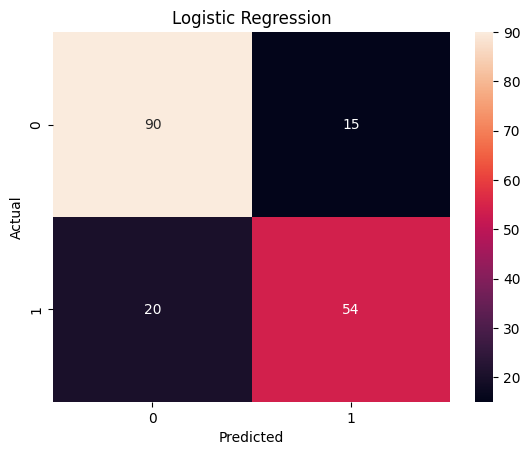

In [43]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression")

plt.show()

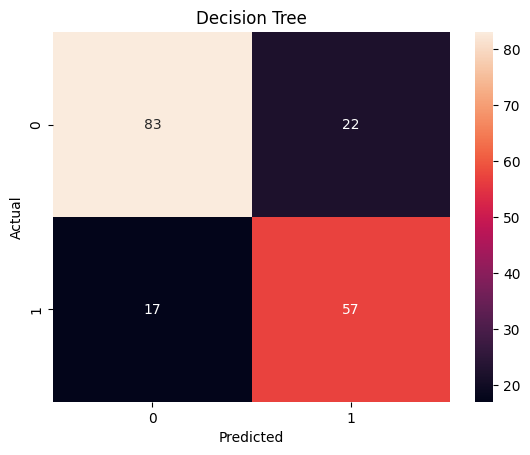

In [44]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree")

plt.show()

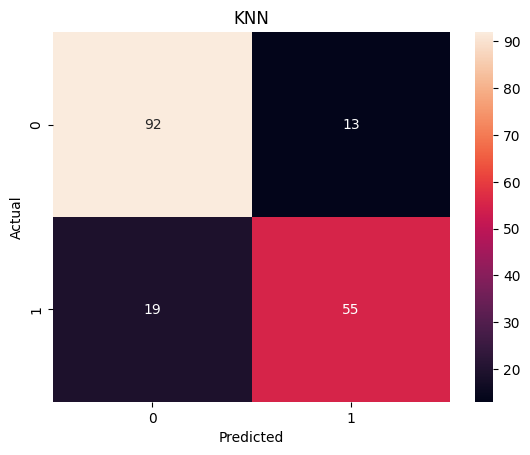

In [45]:
cm = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN")

plt.show()

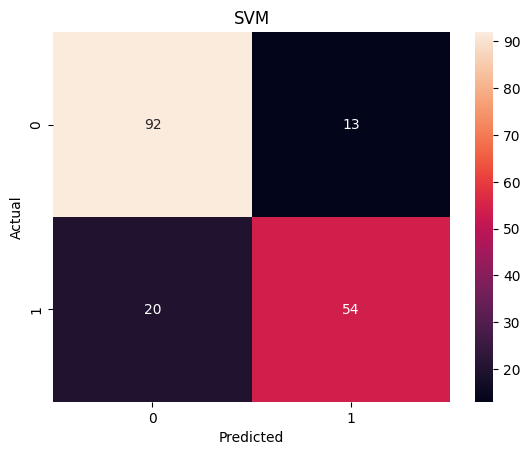

In [46]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM")

plt.show()

## Correlation Heatmap

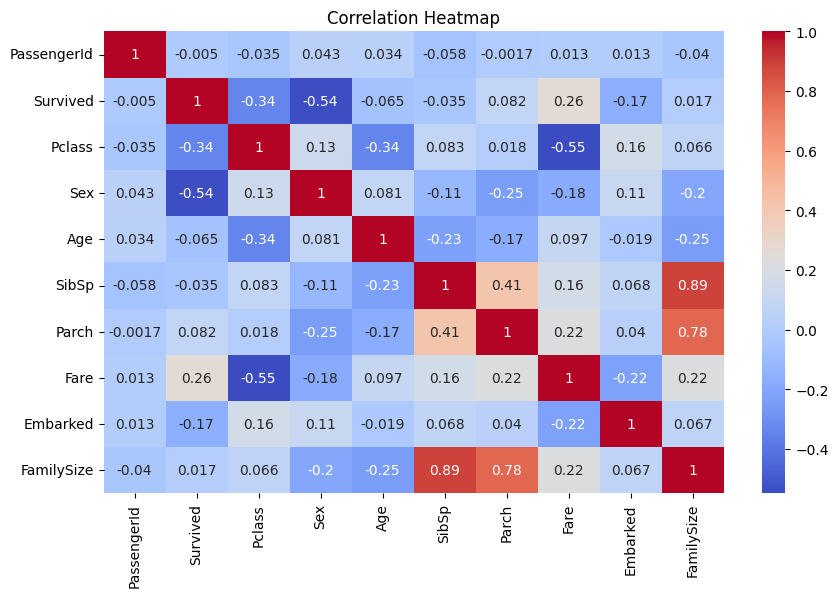

In [47]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Observation:

Sex, Pclass, Fare, and FamilySize showed notable relationships with the target variable Survived. These features contribute significantly to prediction performance.

## Outlier Analysis

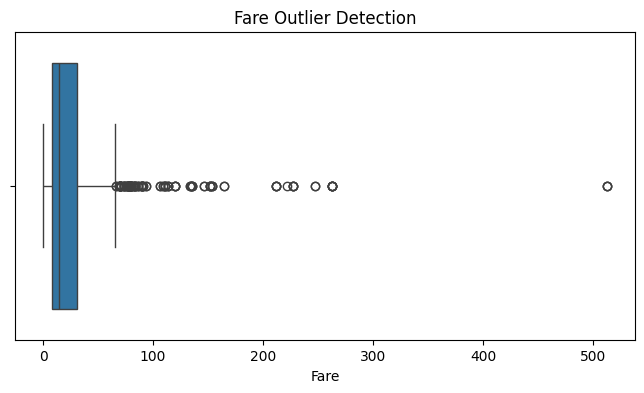

In [48]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Fare'])
plt.title("Fare Outlier Detection")
plt.show()

## Feature Importance (Decision Tree)

In [49]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
1,Sex,0.310280
5,Fare,0.241095
2,Age,0.207785
0,Pclass,0.117313
7,FamilySize,0.073828
3,SibSp,0.021498
6,Embarked,0.020040
4,Parch,0.008161


Observation:

The most important features identified by the Decision Tree model were Sex, Fare, Age, and Pclass. These features had the greatest influence on survival prediction.

## KNN Hyperparameter Tuning

In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for k in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    print("K =", k,
          "Accuracy =",
          accuracy_score(y_test, y_pred))

K = 1 Accuracy = 0.7821229050279329
K = 2 Accuracy = 0.8100558659217877
K = 3 Accuracy = 0.7988826815642458
K = 4 Accuracy = 0.7988826815642458
K = 5 Accuracy = 0.8212290502793296
K = 6 Accuracy = 0.8100558659217877
K = 7 Accuracy = 0.8100558659217877
K = 8 Accuracy = 0.7988826815642458
K = 9 Accuracy = 0.7932960893854749
K = 10 Accuracy = 0.7877094972067039


## Simple Cross Validation

In [51]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    X,
    y,
    cv=5
)

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [0.66480447 0.6741573  0.71910112 0.73033708 0.71910112]
Mean Accuracy: 0.7015002196974451


## Comparison Table

In [52]:
results = pd.DataFrame({

'Model':[
'Logistic Regression',
'Decision Tree',
'KNN',
'SVM'
],

'Accuracy':[
accuracy_lr,
accuracy_dt,
accuracy_knn,
accuracy_svm
]

})

results

,Model,Accuracy
0,Logistic Regression,0.804469
1,Decision Tree,0.782123
2,KNN,0.821229
3,SVM,0.815642


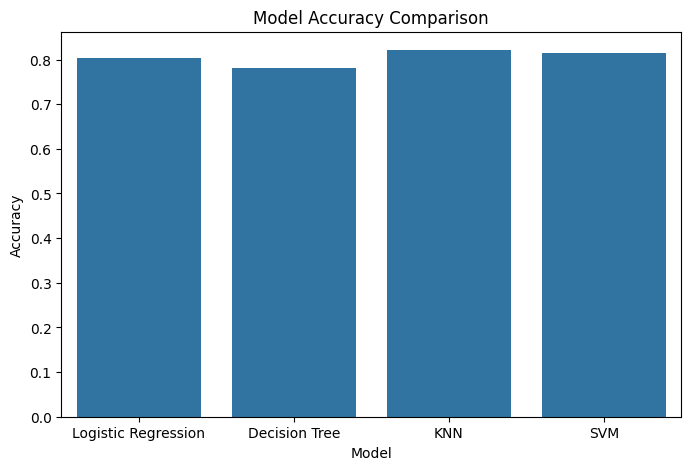

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Accuracy Comparison")

plt.show()

In [54]:
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

comparison = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','KNN','SVM'],
    'Accuracy':[
        accuracy_lr,
        accuracy_dt,
        accuracy_knn,
        accuracy_svm
    ],
    'Precision':[
        precision_lr,
        precision_dt,
        precision_knn,
        precision_svm
    ],
    'Recall':[
        recall_lr,
        recall_dt,
        recall_knn,
        recall_svm
    ],
    'F1 Score':[
        f1_lr,
        f1_dt,
        f1_knn,
        f1_svm
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.804469,0.782609,0.729730,0.755245
1,Decision Tree,0.782123,0.721519,0.770270,0.745098
2,KNN,0.821229,0.808824,0.743243,0.774648
3,SVM,0.815642,0.805970,0.729730,0.765957


In [55]:
results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,KNN,0.821229
3,SVM,0.815642
0,Logistic Regression,0.804469
1,Decision Tree,0.782123


# Conclusion

In this project, the Titanic dataset was analyzed and a complete machine learning workflow was performed, including data cleaning, data manipulation, exploratory data analysis (EDA), feature engineering, and model building.

Four classification algorithms were implemented to predict passenger survival:

1. Logistic Regression
2. Decision Tree
3. K-Nearest Neighbors (KNN)
4. Support Vector Machine (SVM)

The models were evaluated using Accuracy, Precision, Recall, and F1-Score. The accuracy comparison showed the following results:

- KNN: 82.12%
- SVM: 81.56%
- Logistic Regression: 80.45%
- Decision Tree: 78.21%

Among all the models, KNN achieved the highest accuracy of 82.12%, making it the best-performing model for predicting Titanic passenger survival. Therefore, KNN was selected as the final model for this classification task.

This project demonstrates how machine learning techniques can be used to predict survival outcomes based on passenger characteristics such as age, gender, passenger class, fare, and family size.